In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product
from scipy import linalg
from functools import partial

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork, BernoulliNetwork
from src.metrics import (
    TrueRejection,
    FalseRejection,
    Rejection,
    RelativeFrobeniusNorm,
    rv_coefficient_adjusted,
    rv_coefficient,
    ComputeAll,
)
from src.methods import (
    RVPermutationTest,
    FitIndependent,
    LLKRatioTest,
    DiffusionCorrelation,
    CanonicalCorrelationTest
)
from src.solvers import MLE_logistic, ASE, MLE_gaussian
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
from src.plot_functions import plot_grid, plot_with_bands
import scipy.stats as stats
from src.methods import QAP
from src.plot_functions import visualise_latent

In [4]:
rng = np.random.default_rng(42)
copula_types = ['gaussian', 'gaussian', 'gaussian', 'frank', 'rotated_clayton', 'mixture_uniform']

params = {
    'copula_type' : ['gaussian', 'gaussian', 'gaussian', 
                     'clayton', 'gumbel', 'gaussian', 
                     'frank', 'student_t', 'mixture_uniform'],
    'marginals' : ['gaussian', 'gaussian', 'uniform -1 1', 
                   'gaussian', 'gaussian', {'x': 'gaussian', 'z': 'lognormal 0.75'},
                   'gaussian', 'gaussian', 'gaussian'
                   ],
    'weights' : [[], [], [], 
                 [], [], [],
                 [], [], [0.5, 0.5],
                 ],
    
    'correlations' : [[], [], [], 
                      [], [], [],
                      [], [], [0.98, -0.98],
                      ],
    
    'titles': ['Gaussian Independent', 'Gaussian Correlated', 'Square (uniform marginals)',
               'Clayton', 'Gumbel', 'Exponential',
               'Frank', 'Student t', 'Star shaped mixture',
               ],
    'rho': [0, 0.75, 0.75, 0.75,  0.75, 0.75, 0.75, 0.75, 0.75]
}


X_list, Z_list = [], []

for (copula_type, marginals, weights, correlations, rho) in zip(params['copula_type'], params['marginals'], params['weights'], params['correlations'], params['rho']):
    m = GaussianNetwork(n=2000, k=3, rho=rho, rng=rng, 
                        copula_model=copula_type, marginals=marginals,
                        weights=weights, correlations=correlations
                        )
    data = m.generate()
    X_list.append(data['X'])
    Z_list.append(data['Z'])

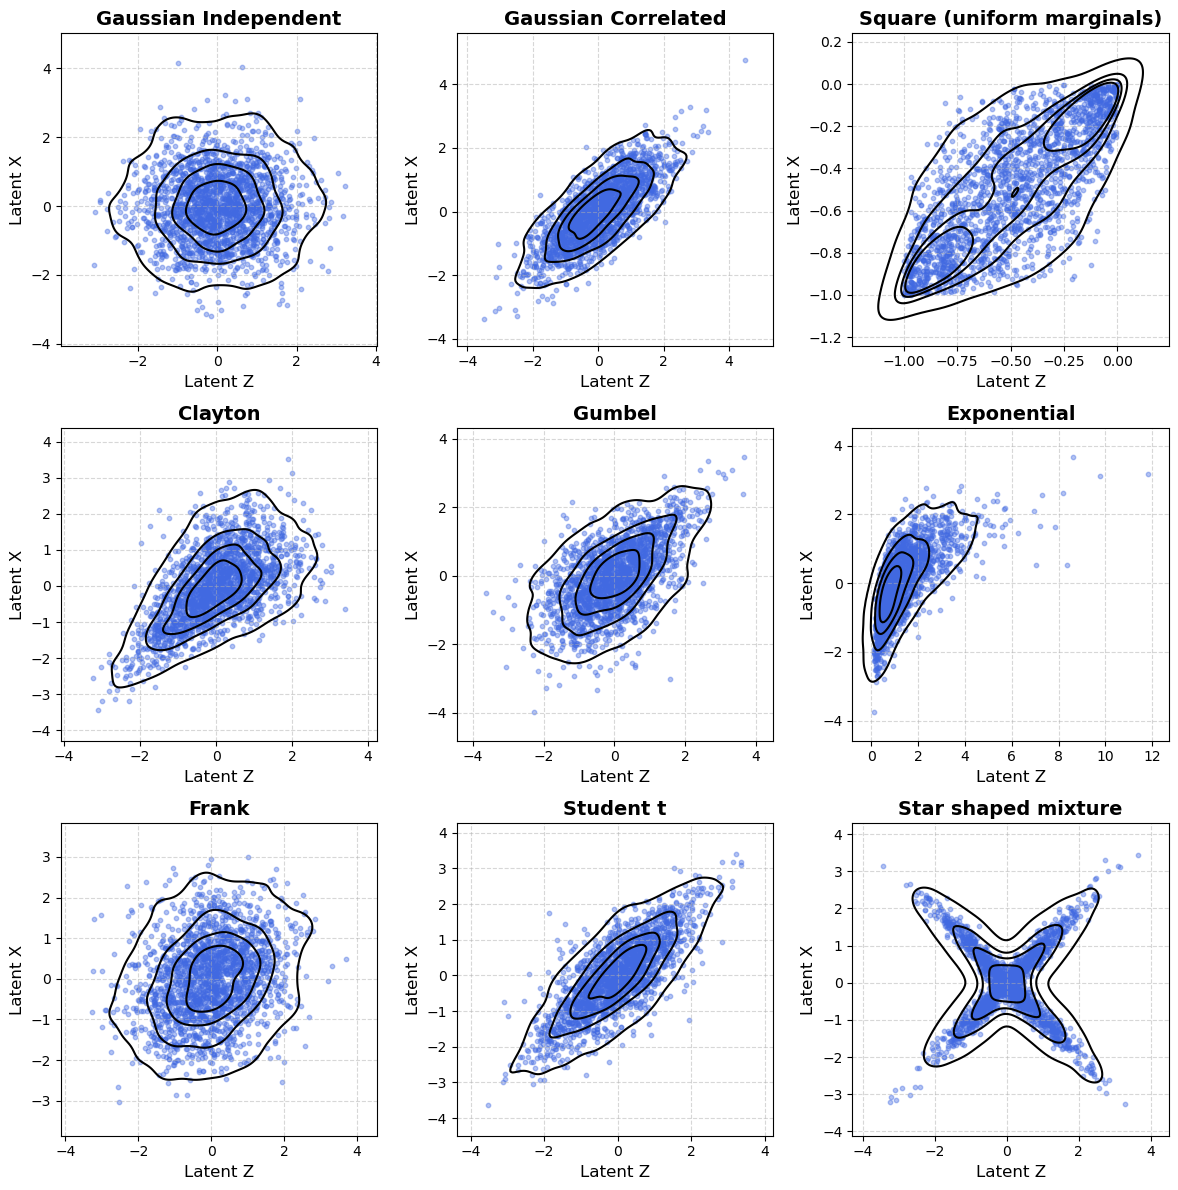

In [5]:
visualise_latent(Z_list, X_list, titles=params['titles'], 
                 shape=(3, 3), figsize=(12, 12), k=0, 
                 kdplot=True, sharex=False, sharey=False)